# Impatto dell'intervallo di sanificazione

Valuta la sensibilità della politica dinamica `c_wall` all'intervallo di sanificazione periodica dei nodi, indicato con $\tau$ (`SANITIZE_INTERVAL_SECONDS`). Configurazione del cluster, workload e grado di conflitto sono fissi in tutti gli scenari: l'unica variabile indipendente è $\tau$.

**Ipotesi.** Curva a U per la latenza di scheduling in funzione di $\tau$. Per $\tau$ piccolo i nodi escono spesso da $\mathcal{N}$ e restano indisponibili in attesa del completamento dei task attivi (la sanificazione attende il drain prima di ripulire); per $\tau$ grande le tracce contestuali non vengono ripulite abbastanza in fretta e i task in conflitto restano bloccati. Esiste quindi un valore intermedio di $\tau$ che minimizza la latenza.

**Nota trasversale su tutte le figure.** La banda attorno alle curve è media ± 1 deviazione standard *tra le repliche*: misura la ripetibilità dell'esperimento, non la dispersione dei singoli task. Per $\tau$ grande la banda si allarga perché in una run entrano meno cicli di sanificazione, e la metrica dipende molto da *quando* cadono quei tick rispetto ai task in esecuzione: la stima è più variabile. L'effetto è coerente in tutte le metriche legate alla sanificazione.

## Configurazione

In [18]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "analysis")
import analysis.utils as utils

RESULTS_ROOT = Path("results")
SCENARIOS_ROOT = Path("scenarios")
FIG_DIR = Path("analysis/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR = Path("analysis/tables")
TAB_DIR.mkdir(parents=True, exist_ok=True)

INTERVALS = [1, 3, 5, 10, 20, 30, 40, 50]
SCENARIOS = [f"sanitize-{i}" for i in INTERVALS]
POINT_KEY = "sanitize_interval_seconds"

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "savefig.bbox": "tight",
    }
)

In [19]:
def band_plot(ax, stats, color, label=None, scale=1.0, marker="o"):
    x = stats.index.to_numpy()
    m = stats["mean"].to_numpy() * scale
    s = stats["std"].fillna(0).to_numpy() * scale
    ax.plot(x, m, marker=marker, color=color, label=label)
    ax.fill_between(x, m - s, m + s, color=color, alpha=0.18, linewidth=0)


def set_x(ax):
    # ax.set_xscale("log")
    ax.set_xticks(INTERVALS)
    ax.set_xticklabels(INTERVALS)
    ax.set_xlabel(r"Intervallo di sanificazione $\tau$ (s)")


## Caricamento dei dati

In [20]:
tasks, nodes, runs = utils.load_scenarios(RESULTS_ROOT, SCENARIOS, POINT_KEY)
scenario_to_dir = {s: SCENARIOS_ROOT / s for s in SCENARIOS}

print(
    f"task totali: {len(tasks)}  |  run: {runs['replica'].count()}  "
    f"|  intervalli: {sorted(tasks['point'].unique())}"
)
runs.groupby("point")["replica"].nunique().rename("repliche")

task totali: 8000  |  run: 40  |  intervalli: [np.int64(1), np.int64(3), np.int64(5), np.int64(10), np.int64(20), np.int64(30), np.int64(40), np.int64(50)]


point
1     5
3     5
5     5
10    5
20    4
30    5
40    4
50    5
Name: repliche, dtype: int64

## 0. Controlli di sanità

**Cosa si verifica.** Che ogni scenario abbia il numero atteso di repliche; che tutti i task siano stati ammessi (nessuna TaskRequest rifiutata da Gatekeeper); che nessuna run sia andata in timeout; che non esistano rifiuti di scheduling per cause diverse da `c_wall`/taint (`rifiuti_other` deve essere 0); e che la durata di esecuzione mediana sia coerente con la durata simulata dei task.

**Perché conta.** Autorizza a fidarsi del resto: se una run ha task non ammessi, in timeout o rifiutati per cause anomale, i suoi numeri non sono confrontabili con gli altri scenari.

In [21]:
checks = []
for point, g in tasks.groupby("point"):
    checks.append(
        {
            "intervallo": point,
            "repliche": g["replica"].nunique(),
            "task": len(g),
            "ammessi_ok": bool(g["admitted"].sum() == len(g)),
            "rifiuti_other": int(g["n_attempts_other"].sum()),
            "timeout": int(g["timed_out"].sum()),
            "execution_mediana": round(g["execution_s"].median(), 2),
        }
    )
display(pd.DataFrame(checks).set_index("intervallo"))


,repliche,task,ammessi_ok,rifiuti_other,timeout,execution_mediana
intervallo,,,,,,
1,5,1000,True,0,0,21.27
3,5,1000,True,0,0,21.28
5,5,1000,True,0,0,21.26
10,5,1000,True,0,0,21.25
20,4,1000,True,0,0,21.29
30,5,1000,True,0,0,21.27
40,4,1000,True,0,0,21.29
50,5,1000,True,0,0,21.35


## 1. Parametri dell'esperimento

Riepilogo dei parametri fissi (identici in tutti gli scenari, per isolare l'effetto del solo intervallo) e della griglia della variabile indipendente. Esportato in LaTeX. La durata dei task (10s) fissa la posizione attesa del braccio sinistro della U: sotto quella soglia l'intervallo diventa più corto del tempo di drain dei nodi.

In [22]:
r0 = runs.iloc[0]
params = pd.DataFrame(
    {
        "Parametro": [
            "Contesti $K$",
            "Densità di conflitto $\\rho$",
            "Task per run $N$",
            "Rate di sottomissione",
            "Durata task",
            "Nodi worker",
            "Repliche",
            "Intervalli valutati $\\tau$",
        ],
        "Valore": [
            int(tasks["context"].str.extract(r"(\d+)").astype(int).max().iloc[0]),
            r0["conflict_density"],
            int(r0["tasks"]),
            f"1 ogni {r0['rate_seconds']:g}s",
            f"{r0['task_duration_seconds']:g}s",
            nodes["node"].nunique(),
            int(runs.groupby("point")["replica"].nunique().max()),
            ", ".join(f"{i}s" for i in INTERVALS),
        ],
    }
).set_index("Parametro")
display(params)
params.to_latex(TAB_DIR / "sanitize_parametri.tex", escape=False)


,Valore
Parametro,
Contesti $K$,10
Densità di conflitto $\rho$,0.5
Task per run $N$,200
Rate di sottomissione,1 ogni 1s
Durata task,20s
Nodi worker,5
Repliche,5
Intervalli valutati $\tau$,"1s, 3s, 5s, 10s, 20s, 30s, 40s, 50s"


## 2. Curva principale: latenza di scheduling

**Cosa si valuta.** La latenza di scheduling per task (dalla sottomissione al binding del pod), media tra repliche, in funzione di $\tau$. È la metrica principale e la misura "per-task": quanto attende il singolo task.

**Cosa dice il grafico.** La U attesa: minimo netto a $\tau=10$s, risalita a sinistra (nodi troppo spesso indisponibili perché continuamente in sanificazione) e risalita marcata a destra (tracce ripulite troppo di rado, task in conflitto bloccati più a lungo). Il minimo individua il valore di $\tau$ che minimizza la latenza. Le bande sono strette nella parte sinistra e si allargano a destra, dove i cicli di sanificazione per run sono meno numerosi e la stima più variabile.

La media è tirata verso l'alto dalla coda dei task bloccati: la distribuzione è bimodale (task veloci non bloccati contro task in lunga attesa). La forma completa di questa distribuzione è nella CDF della sezione 5.

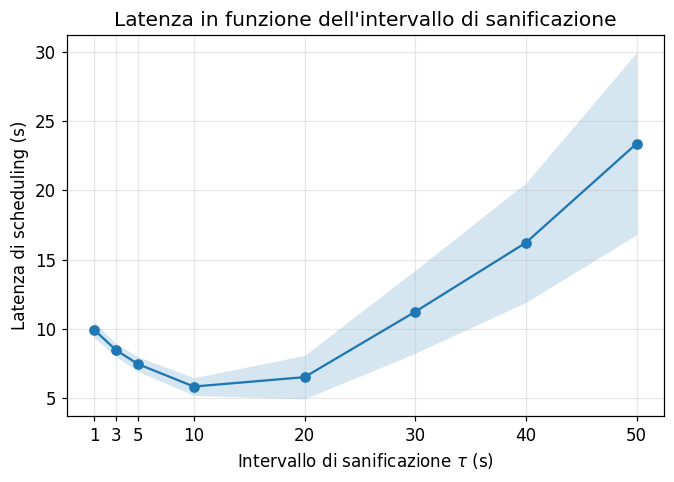

Minimo della latenza media all'intervallo = 10s (5.849s)


In [23]:
lat = utils.per_point_stat(tasks, "latency_s", "mean")
med = utils.per_point_stat(tasks, "latency_s", "median")
p95 = utils.per_point_stat(tasks, "latency_s", lambda s: np.percentile(s, 95))

fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, lat, "#1f77b4")
set_x(ax)
ax.set_ylabel("Latenza di scheduling (s)")
ax.set_title("Latenza in funzione dell'intervallo di sanificazione")
fig.savefig(FIG_DIR / "sanitize_latenza.png")
plt.show()

opt = lat["mean"].idxmin()
print(f"Minimo della latenza media all'intervallo = {opt}s ({lat['mean'].min():.3f}s)")


## 3. Perché la U ha quella forma

Due letture spiegano il meccanismo dietro la curva.

**Ripartizione per causa di blocco.** Ogni task bloccato è classificato per causa: `taint` (nodo fuori da $\mathcal{N}$, in sanificazione), `wall` (tracce contestuali in conflitto), `mixed` (entrambe durante l'attesa), `none` (mai bloccato). Per $\tau$ piccolo domina la componente `taint`, perché i nodi passano gran parte del tempo in sanificazione; questa componente si assottiglia avvicinandosi al minimo della U e quasi scompare per $\tau$ grande, dove resta dominante `mixed` (blocco legato alle tracce non ancora ripulite). Il minimo dei blocchi per taint coincide col minimo della latenza: conferma diretta dell'ipotesi. Le barre sommano a 1 per costruzione.

**Attesa dei task bloccati.** Tempo medio che un task bloccato attende prima di essere schedulato. È quasi piatto e basso fino al minimo della U, poi cresce con $\tau$ perché lo sblocco di un task avviene solo al successivo ciclo di sanificazione del nodo: $\tau$ più grande, attesa più lunga. La banda si allarga a destra per la minore stabilità della stima quando i cicli per run diminuiscono.

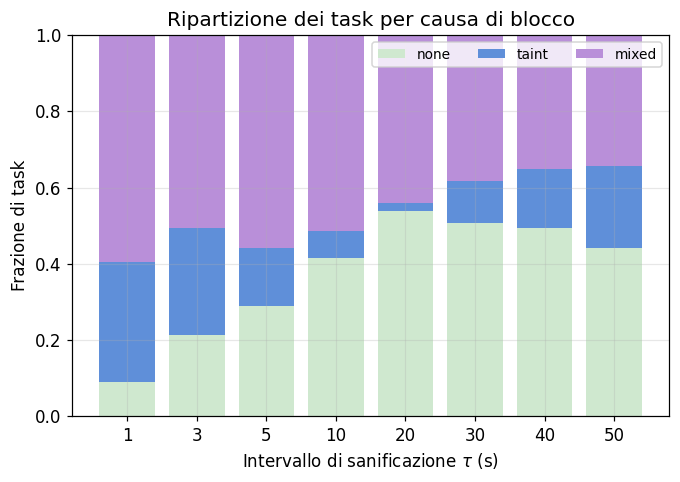

In [24]:
frac = utils.block_fraction_by_cause(tasks)
order = [c for c in ["none", "wall", "taint", "mixed", "other"] if c in frac.columns]
frac = frac[order]
colori = {"none": "#cfe8cf", "wall": "#d95f5f", "taint": "#5f8fd9", "mixed": "#b98fd9", "other": "#999999"}
x = np.arange(len(frac))
bottom = np.zeros(len(frac))
fig, ax = plt.subplots(figsize=(7, 4.5))
for c in order:
    ax.bar(x, frac[c].values, bottom=bottom, label=c, color=colori.get(c))
    bottom += frac[c].values
ax.set_xticks(x)
ax.set_xticklabels(frac.index)
ax.set_ylim(0, 1)
ax.set_xlabel(r"Intervallo di sanificazione $\tau$ (s)")
ax.set_ylabel("Frazione di task")
ax.set_title("Ripartizione dei task per causa di blocco")
ax.legend(ncol=len(order), fontsize=9, loc="upper right")
fig.savefig(FIG_DIR / "sanitize_cause_blocco.png")
plt.show()


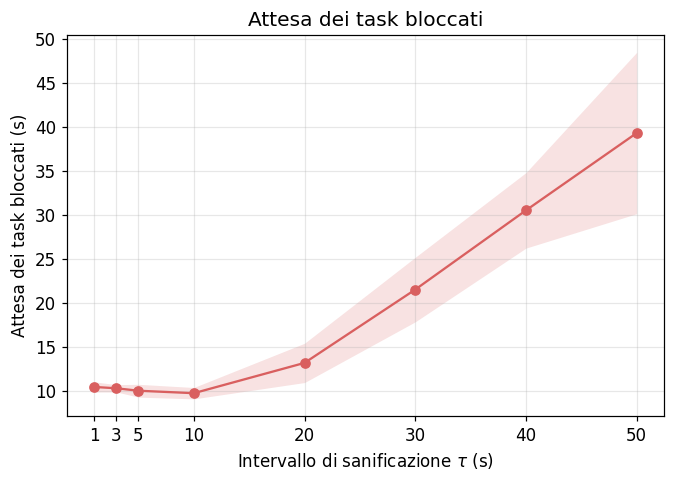

In [25]:
wait = utils.per_point_stat(tasks[tasks["blocked"]], "wait_s", "mean")
fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, wait, "#d95f5f")
set_x(ax)
ax.set_ylabel("Attesa dei task bloccati (s)")
ax.set_title("Attesa dei task bloccati")
fig.savefig(FIG_DIR / "sanitize_attesa.png")
plt.show()


## 4. Disponibilità dei nodi

**Cosa si valuta.** Frazione di tempo in cui i nodi worker sono fuori da $\mathcal{N}$ (taint di sanificazione attivo), integrata sull'intera durata della run e mediata su nodi e repliche, in funzione di $\tau$. È la controparte del fenomeno vista dal lato cluster, non dal lato task.

**Cosa dice il grafico.** Andamento monotono decrescente, da circa il 90% a $\tau=1$s fino a circa il 40% a $\tau=50$s: $\tau$ più piccolo, più spesso i nodi entrano in sanificazione e vi restano finché i task attivi non completano, quindi maggiore l'indisponibilità. Spiega il braccio sinistro della U dal punto di vista dell'infrastruttura: per $\tau$ piccolo i task non trovano nodi disponibili non per le tracce, ma perché i nodi sono continuamente in pulizia. Le bande sono strette su tutta la griglia, segno che con questo carico la stima dell'indisponibilità è stabile.

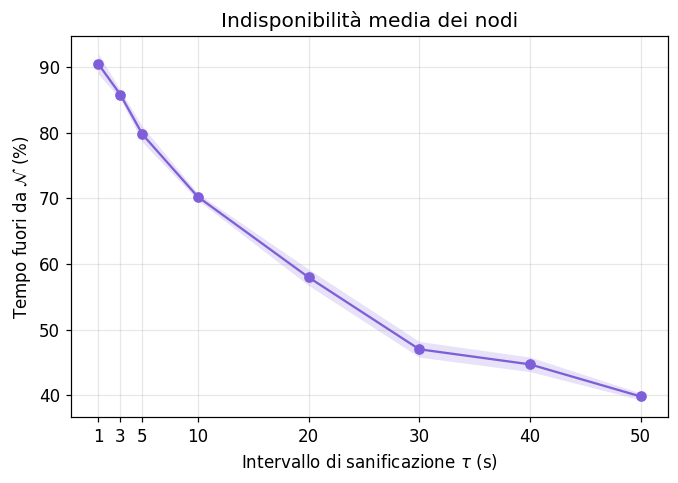

In [26]:
unavail = utils.node_unavailability(nodes, runs)
fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, unavail, "#7f5fd9", scale=100)
set_x(ax)
ax.set_ylabel(r"Tempo fuori da $\mathcal{N}$ (%)")
ax.set_title("Indisponibilità media dei nodi")
fig.savefig(FIG_DIR / "sanitize_disponibilita.png")
plt.show()


## 5. Distribuzione cumulata della latenza

**Come si legge.** Per ogni valore $x$ sull'asse orizzontale (una latenza), la curva dà la frazione di task schedulati entro quel tempo. Esempio: se a x=5s la curva vale 0.8, l'80% dei task è stato schedulato entro 5 secondi. Ogni curva è un intervallo; confrontarle mostra come cambia l'intera distribuzione delle latenze, non solo la media.

**Cosa indica ogni curva.** Tre elementi su ciascuna:
- *altezza vicino all'origine* (gradino verticale iniziale): frazione di task **non bloccati**, schedulati subito. A intervallo breve sale quasi verticale fino a valori alti; a intervallo lungo parte più in basso;
- *coda a destra*: popolazione dei task **bloccati**; quanto la curva si allunga prima di 1.0 misura le latenze peggiori. A 45s striscia oltre 100s, a 1s raggiunge 1.0 in pochi secondi;
- *pendenza*: ripida = latenze concentrate, distesa = latenze sparse.

**Cosa dice il grafico.** Al crescere dell'intervallo il gradino iniziale si abbassa e la coda si allunga: cresce sia la frazione di task bloccati sia il tempo d'attesa. È la giustificazione visiva della bimodalità: le due popolazioni appaiono come gradino più coda, e la coda si ingrossa con l'intervallo.

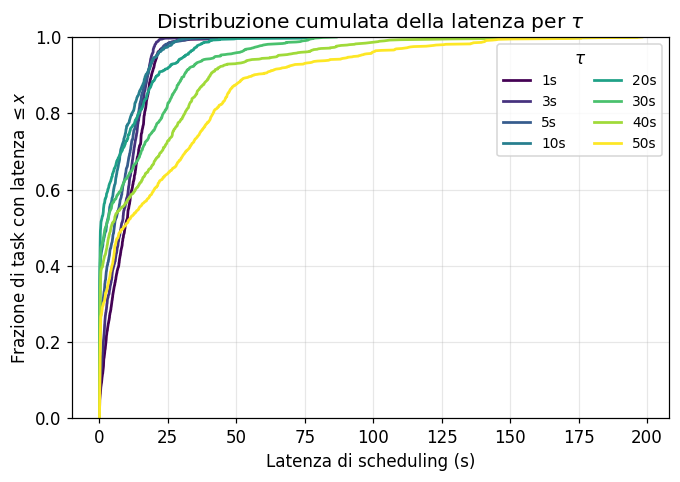

In [27]:
cmap = plt.get_cmap("viridis")
fig, ax = plt.subplots(figsize=(7, 4.5))
for k, point in enumerate(INTERVALS):
    x, y = utils.ecdf(tasks[tasks["point"] == point]["latency_s"])
    ax.plot(x, y, ls="-", lw=1.8, color=cmap(k / max(1, len(INTERVALS) - 1)), label=f"{point}s")
ax.set_xlabel("Latenza di scheduling (s)")
ax.set_ylabel(r"Frazione di task con latenza $\leq x$")
ax.set_ylim(0, 1)
ax.set_title(r"Distribuzione cumulata della latenza per $\tau$")
ax.legend(title=r"$\tau$", ncol=2, fontsize=9)
fig.savefig(FIG_DIR / "sanitize_cdf.png")
plt.show()


## 6. Makespan

**Cosa si valuta.** Il makespan è il tempo dal primo task sottomesso all'ultimo completato: quanto impiega l'intero lotto a smaltirsi. Un solo numero per run (media tra repliche), non una media di valori per-task.

**Per-task vs per-batch.** Latenza (sez. 2) e makespan misurano cose diverse e complementari:
- la *latenza* è per-task, il costo dal punto di vista del singolo task ("quanto aspetto io");
- il *makespan* è per-batch, il costo di sistema ("quanto ci mette tutto il carico a finire").

Due conseguenze. Primo, il makespan **contiene per costruzione la durata della sottomissione**: 100 task a 1/s richiedono già 100s solo per essere spediti, quindi il makespan parte da lì e vi aggiunge la coda finale. È il motivo per cui i suoi valori stanno sui 115–140s mentre la latenza per-task sta sui 2–17s. Secondo, le attese dei task bloccati **si sovrappongono nel tempo**: se molti task attendono in parallelo, la latenza media sale molto ma il makespan cresce poco, perché quelle attese sono concorrenti. Il makespan quindi *ridimensiona* l'impatto: il singolo task può attendere ~17s, ma il batch nel complesso rallenta solo di ~20s su ~120. Mostrarlo accanto alla latenza evita di sovrastimare l'effetto della sanificazione.

**Cosa dice il grafico.** La U è molto più schiacciata che nella latenza per-task, perché dominata dalla componente costante di sottomissione e dalla parallelizzazione delle attese. La banda si allarga a destra per lo stesso effetto pochi-tick-per-run.

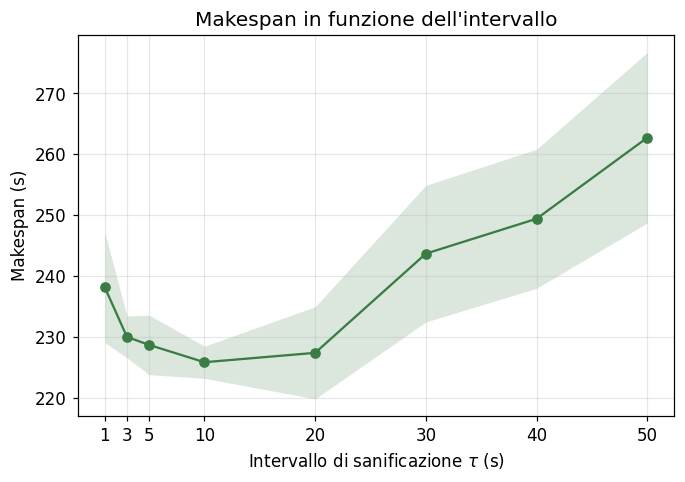

In [28]:
mk = runs.groupby("point")["makespan_s"].agg(["mean", "std"]).sort_index()
fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, mk, "#3a7d44")
set_x(ax)
ax.set_ylabel("Makespan (s)")
ax.set_title("Makespan in funzione dell'intervallo")
fig.savefig(FIG_DIR / "sanitize_makespan.png")
plt.show()


## 7. Tabella riassuntiva

Una riga per intervallo con tutte le metriche principali (latenza media/mediana/p95, % bloccati, attesa media, indisponibilità, makespan). Esportata in LaTeX per l'inclusione diretta in tesi. È il riferimento numerico da citare nel testo a supporto delle figure.

In [29]:
summary = pd.DataFrame(index=lat.index)
summary["Latenza media (s)"] = lat["mean"].round(3)
summary["Dev. std (s)"] = lat["std"].round(3)
summary["Mediana (s)"] = med["mean"].round(3)
summary["p95 (s)"] = p95["mean"].round(3)
summary["Bloccati (%)"] = (tasks.groupby("point")["blocked"].mean() * 100).round(1)
summary["Attesa media (s)"] = wait["mean"].round(2)
summary["Fuori da N (%)"] = (unavail["mean"] * 100).round(1)
summary["Makespan (s)"] = mk["mean"].round(2)
summary.index.name = r"$\tau$ (s)"
display(summary)
summary.to_latex(TAB_DIR / "sanitize_riepilogo.tex", escape=False)
print("Figure in", FIG_DIR, "| tabelle in", TAB_DIR)


,Latenza media (s),Dev. std (s),Mediana (s),p95 (s),Bloccati (%),Attesa media (s),Fuori da N (%),Makespan (s)
$\tau$ (s),,,,,,,,
1,9.942,0.561,9.344,21.104,91.1,10.42,90.5,238.12
3,8.458,0.472,7.988,19.066,78.8,10.27,85.8,229.98
5,7.455,0.527,5.422,20.434,71.2,9.99,79.7,228.66
10,5.849,0.639,2.440,20.675,58.4,9.71,70.2,225.81
20,6.528,1.567,0.666,27.896,47.2,13.16,58.0,227.36
30,11.245,2.998,2.999,42.545,49.2,21.51,47.0,243.67
40,16.224,4.305,5.501,61.207,50.6,30.53,44.7,249.40
50,23.369,6.573,9.775,88.244,56.0,39.33,39.8,262.74


Figure in analysis\figures | tabelle in analysis\tables


## 8. Significatività statistica

I test seguenti verificano se gli andamenti osservati sono statisticamente supportati o attribuibili al caso. L'unità indipendente è la **replica**: ogni replica fornisce un valore aggregato (la latenza media della run) per ciascun intervallo, e i test confrontano queste serie. Usare i valori per-task tratterebbe task correlati della stessa run come indipendenti, gonfiando la significatività. Data la scarsa numerosità (repliche per punto) si usano test **non parametrici**, che non assumono la distribuzione dei dati.

Nota sulla potenza: con poche repliche i test hanno potenza limitata, quindi un risultato non significativo va letto come "campioni insufficienti a dimostrarlo", non come "nessun effetto".

In [30]:
from scipy import stats

# Una latenza media per (intervallo, replica): le repliche sono le unità.
lat_by_point = utils.per_replica_values(tasks, "latency_s", "mean")
points_sorted = sorted(lat_by_point)
print("valori per punto (latenza media di replica):")
for p in points_sorted:
    vals = lat_by_point[p]
    print(f"  {p:>4}s : n={len(vals)}  {[round(v, 2) for v in vals]}")


valori per punto (latenza media di replica):
     1s : n=5  [9.84, 9.81, 9.58, 9.56, 10.92]
     3s : n=5  [8.97, 8.87, 8.47, 7.97, 8.0]
     5s : n=5  [8.26, 7.18, 7.63, 7.35, 6.86]
    10s : n=5  [5.82, 5.11, 6.77, 5.44, 6.1]
    20s : n=4  [8.68, 5.74, 5.08, 6.6]
    30s : n=5  [11.48, 12.33, 10.62, 15.03, 6.77]
    40s : n=4  [17.44, 12.45, 13.23, 21.78]
    50s : n=5  [23.66, 15.37, 32.52, 19.18, 26.1]


### 8.1 Effetto complessivo dell'intervallo (Kruskal–Wallis)

**Cosa fa.** Mette insieme tutte le latenze medie per replica di tutti i valori di $\tau$, le ordina e ne assegna il rango, poi verifica se i ranghi si distribuiscono in modo uniforme tra i gruppi o se qualche valore di $\tau$ raccoglie sistematicamente i ranghi più bassi (latenze piccole) o più alti (latenze grandi). È l'estensione non parametrica dell'ANOVA a più gruppi.

**Cosa si vuole ricavare.** Se l'intervallo di sanificazione $\tau$, nel suo complesso, abbia un effetto sulla latenza, cioè se almeno un valore di $\tau$ differisce dagli altri. È il test "ombrello" che fonda l'intero esperimento: senza un effetto complessivo significativo, discutere la forma della curva non avrebbe basi.

**Possibili esiti.** Un p-value basso (sotto 0.05) indica che $\tau$ influenza la latenza in modo statisticamente significativo, e la variazione osservata lungo la griglia non è rumore. Un p-value alto indicherebbe assenza di effetto rilevabile (o campioni insufficienti a rilevarlo).

In [31]:
groups = [lat_by_point[p] for p in points_sorted]
H, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis: H = {H:.3f}, p = {p_kw:.2e}")
print(
    "=> l'intervallo influenza la latenza in modo significativo"
    if p_kw < 0.05
    else "=> nessun effetto significativo rilevato (attenzione alla potenza)"
)


Kruskal-Wallis: H = 31.868, p = 4.30e-05
=> l'intervallo influenza la latenza in modo significativo


### 8.2 Il minimo è un punto o una regione? (Mann–Whitney U)

**Cosa fa.** Confronta la latenza al valore di $\tau$ di minimo osservato con quella dei suoi **due valori adiacenti** nella griglia (il precedente e il successivo). Per ogni coppia, il test ordina insieme i valori dei due gruppi e conta quante volte un valore supera l'altro: separazione netta se un gruppo è sistematicamente più basso, sovrapposizione se sono indistinguibili. È il test non parametrico per due campioni indipendenti.

**Cosa si vuole ricavare.** Non che il minimo sia più basso degli estremi lontani (ovvio e privo di interesse), ma se il minimo sia **statisticamente distinguibile dai suoi vicini**. Questo risponde alla domanda vera: l'ottimo è un singolo valore di $\tau$ ben definito, oppure una regione piatta in cui più valori vicini danno prestazioni equivalenti?

**Possibili esiti.** Se entrambi i confronti col vicino sono significativi, il minimo è un punto distinto e si può indicare quel valore di $\tau$ come ottimo. Se uno o entrambi non sono significativi, i punti coinvolti formano un plateau: la conclusione corretta diventa che l'ottimo è una *regione* di $\tau$, non un valore singolo. L'ultima cella dichiara automaticamente quale dei due casi si verifica.

In [32]:
opt = min(points_sorted, key=lambda p: np.mean(lat_by_point[p]))
idx = points_sorted.index(opt)
neighbours = []
if idx > 0:
    neighbours.append(points_sorted[idx - 1])
if idx < len(points_sorted) - 1:
    neighbours.append(points_sorted[idx + 1])

print(f"minimo osservato: {opt}s (latenza media {np.mean(lat_by_point[opt]):.2f}s)\n")

mw_results = {}
for other in neighbours:
    U, p_mw = stats.mannwhitneyu(
        lat_by_point[opt], lat_by_point[other], alternative="two-sided"
    )
    mw_results[other] = p_mw
    verdict = "distinguibile" if p_mw < 0.05 else "NON distinguibile"
    print(f"{opt}s vs {other}s : U = {U:.1f}, p = {p_mw:.2e}  ({verdict})")


minimo osservato: 10s (latenza media 5.85s)

10s vs 5s : U = 0.0, p = 7.94e-03  (distinguibile)
10s vs 20s : U = 9.0, p = 9.05e-01  (NON distinguibile)


### 8.3 Conclusione: minimo puntuale o regione ottimale

In base agli esiti dei confronti col vicino, la cella dichiara se l'ottimo è un singolo intervallo (minimo distinguibile da entrambi i vicini) o una regione (almeno un vicino indistinguibile). È la formulazione da riportare in tesi.

In [33]:
indistinguibili = [p for p, pv in mw_results.items() if pv >= 0.05]
if not indistinguibili:
    conclusione = (
        f"L'ottimo è un minimo puntuale a {opt}s: la latenza vi è "
        f"significativamente inferiore rispetto a entrambi gli intervalli adiacenti."
    )
else:
    regione = sorted(set([opt] + indistinguibili))
    conclusione = (
        f"L'ottimo è una regione: gli intervalli "
        f"{', '.join(f'{p}s' for p in regione)} non sono statisticamente "
        f"distinguibili tra loro in latenza, quindi vanno considerati equivalenti."
    )
print(conclusione)


L'ottimo è una regione: gli intervalli 10s, 20s non sono statisticamente distinguibili tra loro in latenza, quindi vanno considerati equivalenti.


### 8.4 Tabella dei test

Riepilogo dei risultati per l'inclusione in tesi.

In [34]:
rows = []
rows.append(
    {
        "test": "Kruskal-Wallis (effetto complessivo)",
        "statistica": f"H = {H:.3f}",
        "p-value": f"{p_kw:.2e}",
        "esito": "significativo" if p_kw < 0.05 else "n.s.",
    }
)
for other in neighbours:
    U, p_mw = stats.mannwhitneyu(
        lat_by_point[opt], lat_by_point[other], alternative="two-sided"
    )
    rows.append(
        {
            "test": f"Mann-Whitney {opt}s vs {other}s",
            "statistica": f"U = {U:.1f}",
            "p-value": f"{p_mw:.2e}",
            "esito": "significativo" if p_mw < 0.05 else "n.s.",
        }
    )
tests_df = pd.DataFrame(rows).set_index("test")
display(tests_df)
tests_df.to_latex(TAB_DIR / "sanitize_test_statistici.tex", escape=True)


,statistica,p-value,esito
test,,,
Kruskal-Wallis (effetto complessivo),H = 31.868,4.30e-05,significativo
Mann-Whitney 10s vs 5s,U = 0.0,7.94e-03,significativo
Mann-Whitney 10s vs 20s,U = 9.0,9.05e-01,n.s.
